# <font color=#0099CC>**CONV1D: V_in = 30, V_out = 90**</font>

## <font color=#0099CC>**0. INTRODUCCIÓN**</font>

### <font color=#336699>**0.1. Objetivo de este cuaderno**</font>

Notebook individual para una única combinación del grid 4×4 (**V_in=30**, **V_out=90**). Patrón «1 notebook = 1 combo»: se entrena un modelo **Conv1D** con esa pareja de ventanas y se persiste mediante `BestRunTracker` (callback compartido) la **mejor ejecución histórica** del combo + la última, junto con la curva de entrenamiento. El consolidado de los 16 parciales y los heatmaps los genera `_agregador_conv1d.ipynb`.

Los datos son **log-retornos** multivariantes (23 activos); el MAE se interpreta en esa escala. En esta combinación activamos el escalado `scaler='standard'` (fit **solo** sobre `X_tr`, transform a val/test). La curva incluye como referencia los MAE de los 3 baselines (`buy_and_hold`, `trivial`, `lineal`) para el mismo `(v_in, v_out)`.

**Salidas generadas**:
- `08_results/runs/conv1d/conv1d_vin30_vout90/best.keras` — pesos+arquitectura de la mejor ejecución histórica
- `08_results/runs/conv1d/conv1d_vin30_vout90/best.json` — hparams + MAEs + epoch + timestamp del best
- `08_results/runs/conv1d/conv1d_vin30_vout90/last.json` — última ejecución (auditoría)
- `08_results/runs/conv1d/conv1d_vin30_vout90/history.csv` — append-only (1 fila por ejecución)
- `08_results/tablas/parciales/conv1d_vin30_vout90.csv` — escrito desde best.json (mejor histórica)
- `08_results/curvas/conv1d/conv1d_vin30_vout90.png` — curva con baselines superpuestos

La partición train/val/test es cronológica con semilla fija (`random_state=42`): **no modificar**. Para otra combinación: duplicar este notebook y cambiar **solo** `V_IN` y `V_OUT` en la sección de configuración.

## <font color=#0099CC>**1. ENTORNO DE EJECUCIÓN**</font>

### <font color=#336699>**1.1. Detección Colab / local y rutas del proyecto**</font>

Se configura `BASE`, el acceso a Drive cuando aplica y el `sys.path` para importar utilidades compartidas sin duplicar código.

In [1]:
import os, sys

def detect_env():
    try:
        import google.colab
        return 'colab'
    except ImportError:
        return 'local'

ENV = detect_env()

if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Taller4_DL_MIAX'
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC = os.path.join(BASE, '01_src_compartido')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(f'> Entorno : {ENV}')
print(f'> BASE    : {BASE}')
print(f'> SRC     : {SRC}')

> Entorno : local
> BASE    : /mnt/c/Users/diego/MIAX/11-nn-forecasting-sp/Taller4_DL_MIAX
> SRC     : /mnt/c/Users/diego/MIAX/11-nn-forecasting-sp/Taller4_DL_MIAX/01_src_compartido


## <font color=#0099CC>**2. IMPORTACIONES**</font>

### <font color=#336699>**2.1. Librerías y módulos compartidos**</font>

Stack numérico, TensorFlow/Keras y utilidades de datos y métricas; se inyecta `BASE` en `metrics_utils` antes de cualquier guardado.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from dataset_utils import load_data, create_dataset, get_partitions, TICKERS
import metrics_utils
metrics_utils.BASE_DRIVE = BASE
from metrics_utils import (
    plot_curva,
    BestRunTracker,
    resumen_vs_baselines,
    cargar_best_modelo,
)

print(f'> TensorFlow : {tf.__version__}')
print(f'> GPU        : {tf.config.list_physical_devices("GPU")}')

2026-05-13 23:53:55.760391: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-13 23:53:55.801750: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-13 23:53:56.460489: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


> TensorFlow : 2.13.0
> GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-05-13 23:53:57.788457: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-13 23:53:57.826788: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-13 23:53:57.826870: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


## <font color=#0099CC>**3. CONFIGURACIÓN DEL EXPERIMENTO**</font>

### <font color=#336699>**3.1. Combinación de ventanas e hiperparámetros**</font>

Única celda que cambia al duplicar el notebook para otro par **V_in / V_out**.

In [ ]:
MODELO = 'conv1d'
V_IN, V_OUT = 90, 30

EPOCHS     = 1000
BATCH_SIZE = 100
PATIENCE   = 40

SCALER   = 'standard'   # None | 'standard' | 'minmax'  -- fit SOLO sobre X_tr
VAL_SIZE = 0.2          # tamano del split de validacion

EXP_BASE = None         # si se setea (papermill), redirige todas las salidas a un sandbox

print(f'> Combinacion: V_in={V_IN}, V_out={V_OUT}')
print(f'> Scaler    : {SCALER}')
print(f'> Val size  : {VAL_SIZE}')

In [ ]:
# Redireccion del sandbox: se ejecuta DESPUES de la celda 'parameters'
# (y por tanto despues de la inyeccion de papermill, que ya ha fijado EXP_BASE).
if EXP_BASE:
    import metrics_utils as _m
    _m.BASE_DRIVE = EXP_BASE
    print(f'> [redirect] metrics_utils.BASE_DRIVE = {EXP_BASE}')

## <font color=#0099CC>**4. DESCARGA DE DATOS**</font>

### <font color=#336699>**4.1. Serie multivariante y construcción del dataset**</font>

Precios de cierre ajustados de los 23 activos (vía `yfinance`), transformados a log-retornos. Se construyen las ventanas para esta combinación y se particiona cronológicamente (semilla competición = 42). El scaler se ajusta exclusivamente con los datos de entrenamiento y se aplica con `transform` a val/test (sin data-leakage). `Y` se deja sin escalar.

In [4]:
data, df = load_data()
print(f'> Datos : {data.shape[0]:,} días × {data.shape[1]} activos')
print(f'> Rango : {df.index[0].date()} → {df.index[-1].date()}')

X, Y = create_dataset(data, V_IN, V_OUT)
X_tr, X_val, X_test, Y_tr, Y_val, Y_test, sc = get_partitions(
    X, Y, scaler=SCALER, return_scaler=True, verbose=True, val_size=VAL_SIZE
)

print(f'> X shape: {X.shape}   Y shape: {Y.shape}')
print(f'> Train: {X_tr.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}')
if sc is not None:
    print(f'> Scaler: {type(sc).__name__} fitted on X_tr only')
    print(f'>   mean(X_tr_scaled) ≈ {X_tr.mean():+.4f}   std(X_tr_scaled) ≈ {X_tr.std():.4f}')

> Datos : 16,198 días × 23 activos
> Rango : 1962-01-03 → 2026-05-13
> Scaler: standard fitted on X_tr only — applied to train/val/test
> Particiones — Train:  11576  Val:   2895  Test:   1608
> X shape: (16079, 90, 23)   Y shape: (16079, 23)
> Train: 11,576  Val: 2,895  Test: 1,608
> Scaler: StandardScaler fitted on X_tr only
>   mean(X_tr_scaled) ≈ +0.0000   std(X_tr_scaled) ≈ 1.0000


## <font color=#0099CC>**5. MODELO CONV1D**</font>

### <font color=#336699>**5.1. Arquitectura y compilación**</font>

Cinco bloques Conv1D (32 → 64 → 128 → 256 → 256 filtros, kernel 3, padding `same`) con `BatchNormalization` + `Dropout` tras cada bloque y `MaxPooling1D` tras los bloques 2, 3 y 4 (90 → 45 → 22 → 11 pasos). `GlobalAveragePooling1D` colapsa la dimensión temporal antes del cabezal denso (Dense 128 + Dropout). Regularización L2 en todas las capas Conv. Loss: `mae`.

In [5]:
N_ASSETS = len(TICKERS)  # 23

l2 = regularizers.l2(1e-4)

model = models.Sequential([
    # ── Bloque 1: 90 pasos ──────────────────────────────────────────────────
    layers.Conv1D(32, kernel_size=3, padding='same', activation='relu',
                  input_shape=(V_IN, N_ASSETS), kernel_regularizer=l2),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # ── Bloque 2: 90 → MaxPool → 45 ─────────────────────────────────────────
    layers.Conv1D(64, kernel_size=3, padding='same', activation='relu',
                  kernel_regularizer=l2),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.MaxPooling1D(pool_size=2),

    # ── Bloque 3: 45 → MaxPool → 22 ─────────────────────────────────────────
    layers.Conv1D(128, kernel_size=3, padding='same', activation='relu',
                  kernel_regularizer=l2),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.MaxPooling1D(pool_size=2),

    # ── Bloque 4: 22 → MaxPool → 11 ─────────────────────────────────────────
    layers.Conv1D(256, kernel_size=3, padding='same', activation='relu',
                  kernel_regularizer=l2),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.MaxPooling1D(pool_size=2),

    # ── Bloque 5: 11 pasos ───────────────────────────────────────────────────
    layers.Conv1D(256, kernel_size=3, padding='same', activation='relu',
                  kernel_regularizer=l2),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # ── Cabezal ──────────────────────────────────────────────────────────────
    layers.GlobalAveragePooling1D(),
    layers.Dense(128, activation='relu', kernel_regularizer=l2),
    layers.Dropout(0.5),
    layers.Dense(N_ASSETS),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mae',
)

model.summary()

2026-05-13 23:54:03.171284: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-13 23:54:03.171472: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-13 23:54:03.171538: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-13 23:54:03.335745: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-13 23:54:03.335842: I tensorflow/compile

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 90, 32)            2240      
                                                                 
 batch_normalization (Batch  (None, 90, 32)            128       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 90, 32)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 90, 64)            6208      
                                                                 
 batch_normalization_1 (Bat  (None, 90, 64)            256       
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 90, 64)            0

## <font color=#0099CC>**6. ENTRENAMIENTO**</font>

### <font color=#336699>**6.1. Ajuste con callbacks**</font>

`EarlyStopping` con `restore_best_weights`, `ReduceLROnPlateau` cuando `val_loss` se estanca y `BestRunTracker`, que durante el fit guarda en `best.keras` la mejor época y al terminar:
- escribe siempre `last.json` (última ejecución),
- si la `mae_val` mejora la histórica del combo, pisa `best.json` y el CSV parcial,
- añade una fila a `history.csv` (append-only).

Si la nueva ejecución no mejora, el `best.keras` previo se restaura intacto.

In [ ]:
es = EarlyStopping(
    monitor='val_loss', patience=PATIENCE,
    restore_best_weights=True, verbose=1,
)

rlr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=15,
    min_lr=1e-6, verbose=1,
)

tracker = BestRunTracker(
    MODELO, V_IN, V_OUT,
    datasets=(X_tr, Y_tr, X_val, Y_val, X_test, Y_test), auto_plot=True,
    hparams_extra={
        'batch_size': BATCH_SIZE,
        'patience':   PATIENCE, 
        'epochs_max': EPOCHS,
        'scaler':     SCALER,
    },
)

history = model.fit(
    X_tr, Y_tr,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es, rlr, tracker],
    verbose=2,
)

print(f'> Epochs entrenadas: {len(history.history["loss"])}')
print(f'> Best val_loss   : {min(history.history["val_loss"]):.5f}')

## <font color=#0099CC>**7. MÉTRICAS Y PERSISTENCIA**</font>

### <font color=#336699>**7.1. MAE por partición y comparativa con baselines**</font>

`BestRunTracker` ya ha persistido el `best.keras`, `best.json`, `last.json`, `history.csv` y el CSV parcial (este último siempre con la mejor histórica). Aquí solo:
- dibujamos la curva de entrenamiento con líneas horizontales de los 3 baselines como referencia,
- imprimimos la comparativa MAE modelo-vs-baselines del combo.

`_agregador_conv1d.ipynb` consolidará los 16 parciales en `conv1d_resultados.csv` y generará los heatmaps.

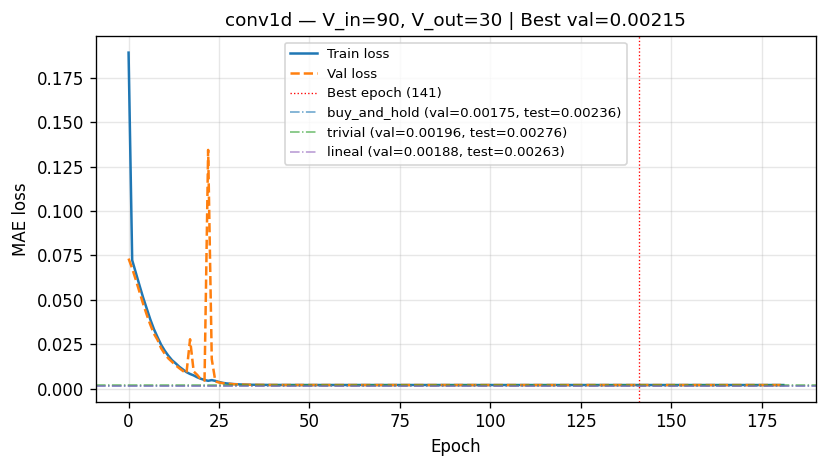

> Comparativa MAE — V_in=90, V_out=30


baseline,n_params,mae_train,mae_val,mae_test,mejora_test_%
conv1d,"367,383",0.00216,0.00215,0.00217,—
buy_and_hold,0,0.00224,0.00175,0.00236,+7.84%
trivial,0,0.00254,0.00196,0.00276,+21.25%
lineal,"47,633",0.00203,0.00188,0.00263,+17.38%



> MAE  train=0.0022  val=0.0022  test=0.0022  params=367,383
> Artefactos en: 08_results/runs/conv1d/conv1d_vin90_vout30/


In [7]:
maes = tracker.maes_last  # MAE train/val/test del best.keras de esta ejecución

plot_curva(history, MODELO, V_IN, V_OUT, mostrar_baselines=True, save=tracker.improved)
plt.show()

resumen_vs_baselines(maes, V_IN, V_OUT, nombre_modelo=MODELO, verbose=True, n_params=model.count_params())


print(f'\n> MAE  train={maes["train"]:.4f}  val={maes["val"]:.4f}  test={maes["test"]:.4f}'
      f'  params={model.count_params():,}')
print(f'> Artefactos en: 08_results/runs/{MODELO}/{MODELO}_vin{V_IN}_vout{V_OUT}/')

## <font color=#0099CC>**8. CONSOLIDACIÓN 4×4**</font>

### <font color=#336699>**8.1. Heatmaps y tabla global**</font>

Los mapas de calor MAE y la tabla completa del modelo **Conv1D** sobre todas las combinaciones no se generan aquí; ejecutar `_agregador_conv1d.ipynb` cuando existan los 16 CSV parciales.